In [49]:
from __future__ import annotations
import re
import difflib
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Iterable

import spacy
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

from matplotlib.ticker import MaxNLocator

In [2]:
_nlp = spacy.blank("en")
_nlp.add_pipe('sentencizer')

In [3]:
def split_into_paragraphs(text: str) -> list[str]:
    """Split raw text into paragraphs on blank lines."""
    return [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]

def load_paragraphs(text) -> list[str]:
    """Split a plain-text file into paragraphs on blank lines."""
    # text = open(path, encoding="utf-8").read()
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    return paragraphs


def paragraph_to_sentences(paragraph: str) -> list[list[str]]:
    """Tokenize a paragraph into a list of sentences, each a list of
    lowercased word tokens (punctuation tokens dropped)."""
    doc = _nlp(paragraph)
    sentences = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if t.is_alpha]
        if tokens:
            sentences.append(tokens)
    return sentences


def ngrams(tokens: list[str], n: int) -> list[tuple[str, ...]]:
    """Slide a window of size n over tokens, one word at a time."""
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

In [4]:
@dataclass
class TrigramCorpus:
    paragraphs: list[str]
    # trigram -> set of paragraph ids it appears in
    trigram_index: dict[tuple[str, ...], set[int]]
    # paragraph id -> set of trigrams it contains
    paragraph_trigrams: dict[int, set[tuple[str, ...]]]
    # trigram -> total occurrence count across the whole text (repeats within
    # a paragraph count multiple times, unlike trigram_index)
    trigram_counts: Counter

def build_trigram_corpus(paragraphs: list[str], n: int = 3) -> TrigramCorpus:
    trigram_index: dict[tuple[str, ...], set[int]] = defaultdict(set)
    paragraph_trigrams: dict[int, set[tuple[str, ...]]] = {}
    trigram_counts: Counter = Counter()
 
    for pid, para in enumerate(paragraphs):
        sents = paragraph_to_sentences(para)
        para_grams: set[tuple[str, ...]] = set()
        for sent in sents:
            sent_grams = ngrams(sent, n)
            trigram_counts.update(sent_grams)  # total occurrences, incl. within-paragraph repeats
            para_grams.update(sent_grams)
        paragraph_trigrams[pid] = para_grams
        for g in para_grams:
            trigram_index[g].add(pid)
 
    return TrigramCorpus(paragraphs, dict(trigram_index), paragraph_trigrams, trigram_counts)



def frequent_trigrams(corpus: TrigramCorpus, min_paragraphs: int = 2):
    """Trigrams appearing in at least `min_paragraphs` distinct paragraphs."""
    return {g: pids for g, pids in corpus.trigram_index.items()
            if len(pids) >= min_paragraphs}

def top_trigrams_by_count(corpus: TrigramCorpus, n: int = 20, min_count: int = 1, offset: int = 0):
    """Trigrams sorted by total occurrence count (descending), the way you'd
    normally think of 'word frequency' -- not paragraph spread. Ties broken
    alphabetically for stable, reproducible output. `offset` lets you grab a
    later slice of the ranking, e.g. offset=10, n=10 for ranks 11-20."""
    items = [(g, c) for g, c in corpus.trigram_counts.items() if c >= min_count]
    items.sort(key=lambda gc: (-gc[1], gc[0]))
    return items[offset:offset + n]


def mine_cooccurring_trigram_sets(
    corpus: TrigramCorpus,
    min_paragraphs: int = 2,
    min_support: float | None = None,
):
    """
    Frequent-itemset mining over trigrams, treating each paragraph as a
    transaction. Returns itemsets of trigrams that recur *together*
    across paragraphs -- e.g. the article's example where 'a description
    of', 'now a description', 'this is now', and 'is now a' all co-occur
    in three different paragraphs.
    """
    freq = frequent_trigrams(corpus, min_paragraphs=min_paragraphs)
    if not freq:
        return pd.DataFrame(columns=["support", "itemsets"])

    # Restrict each paragraph's transaction to only the pre-filtered
    # frequent trigrams -- keeps the itemset search space tractable on
    # a novel-length text.
    transactions = []
    for pid in corpus.paragraph_trigrams:
        items = corpus.paragraph_trigrams[pid] & freq.keys()
        transactions.append([" ".join(g) for g in items])

    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df = pd.DataFrame(te_ary, columns=te.columns_)

    n_paras = len(corpus.paragraphs)
    if min_support is None:
        min_support = min_paragraphs / n_paras

    itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
    itemsets = itemsets[itemsets["itemsets"].apply(len) > 1]  # co-occurring SETS
    return itemsets.sort_values("support", ascending=False).reset_index(drop=True)


In [5]:
def find_long_verbatim_repeats(paragraphs: list[str], n: int = 36):
    """
    Slide an n-word window across each paragraph and find n-grams that
    recur in more than one location (paragraph, position). Long exact
    matches like this are how the original study surfaced the two
    ~500-word verbatim-duplicated sections.
    """
    index: dict[tuple[str, ...], list[tuple[int, int]]] = defaultdict(list)

    for pid, para in enumerate(paragraphs):
        tokens = [t for sent in paragraph_to_sentences(para) for t in sent]
        for i in range(len(tokens) - n + 1):
            g = tuple(tokens[i:i + n])
            index[g].append((pid, i))

    return {g: locs for g, locs in index.items() if len(locs) >= 2}


def find_longest_verbatim_match(paragraphs: list[str], para_a: int, para_b: int):
    """
    Alternative to picking an n up front: use difflib to find the
    longest contiguous matching block of tokens between two paragraphs
    directly. Useful once find_long_verbatim_repeats() has flagged a
    candidate pair.
    """
    tokens_a = [t for sent in paragraph_to_sentences(paragraphs[para_a]) for t in sent]
    tokens_b = [t for sent in paragraph_to_sentences(paragraphs[para_b]) for t in sent]
    matcher = difflib.SequenceMatcher(None, tokens_a, tokens_b, autojunk=False)
    match = matcher.find_longest_match(0, len(tokens_a), 0, len(tokens_b))
    matched_words = tokens_a[match.a: match.a + match.size]
    return matched_words, match

In [6]:
with open('../corpuses/wollstonecraft-corpus/maria.txt') as m:
    maria = m.read()

In [7]:
def clean_gutenberg_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    start_pattern = r"\*\*\*\s*START OF.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.DOTALL | re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.DOTALL | re.IGNORECASE)

    if not start_match or not end_match:
        raise ValueError("Could not locate Gutenberg boundaries.")

    cleaned = text[start_match.end():end_match.start()]

    return cleaned.strip()

In [8]:
maria = clean_gutenberg_text('../corpuses/wollstonecraft-corpus/maria.txt')

In [9]:
import re

def split_by_contents(text):
    """
    Split a Gutenberg text into sections using its CONTENTS page.

    Returns:
        dict[str, str]
    """

    # Find CONTENTS section
    contents_match = re.search(
        r"\n\s*CONTENTS\s*\n",
        text,
        re.IGNORECASE
    )

    if not contents_match:
        raise ValueError("Could not find CONTENTS section.")

    contents_start = contents_match.end()

    # Everything after CONTENTS
    remainder = text[contents_start:]

    lines = remainder.splitlines()

    titles = []
    first_title_pos = None

    # Collect non-blank lines until we encounter
    # the first title repeated in the body.
    for i, line in enumerate(lines):
        stripped = line.strip()

        if not stripped:
            continue

        titles.append(stripped)

        # Look ahead: if this title appears later surrounded
        # by blank lines, we've probably reached the body.
        pattern = (
            r"\n\s*\n\s*"
            + re.escape(stripped)
            + r"\s*\n"
        )

        m = re.search(pattern, remainder)

        if m and m.start() > 0:
            first_title_pos = m.start()
            break

    if first_title_pos is None:
        raise ValueError("Could not determine end of CONTENTS section.")

    contents_text = remainder[:first_title_pos]
    titles = [
        line.strip()
        for line in contents_text.splitlines()
        if line.strip()
    ]

    body = remainder[first_title_pos:]

    # Locate each title in the body
    sections = []

    for title in titles:
        pattern = (
            r"\n\s*\n\s*"
            + re.escape(title)
            + r"\s*\n"
        )

        m = re.search(pattern, body)

        if m:
            sections.append((title, m.start()))

    if not sections:
        raise ValueError("No section headings found in body.")

    # Slice text into sections
    result = {}

    for i, (title, start) in enumerate(sections):
        if i + 1 < len(sections):
            end = sections[i + 1][1]
        else:
            end = len(body)

        result[title] = body[start:end].strip()

    return result

In [10]:
maria_contents = split_by_contents(maria)

In [11]:
def unwrap_gutenberg_paragraphs(text):
    """
    Remove Gutenberg line wrapping while preserving paragraphs.
    """

    # Normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Split into paragraphs
    paragraphs = re.split(r"\n\s*\n+", text)

    cleaned = []

    for para in paragraphs:
        # Replace internal newlines with spaces
        para = re.sub(r"\s*\n\s*", " ", para)

        # Collapse repeated spaces
        para = re.sub(r"\s+", " ", para)

        cleaned.append(para.strip())

    return "\n\n".join(cleaned)

In [12]:
maria = unwrap_gutenberg_paragraphs(maria)
maria[:5000]

'MARIA\n\nor The Wrongs of Woman\n\nby MARY WOLLSTONECRAFT\n\n(1759-1797)\n\nAfter the edition of 1798\n\nCONTENTS\n\nMARIA PREFACE AUTHOR’S PREFACE CHAPTER 1 CHAPTER 2 CHAPTER 3 CHAPTER 4 CHAPTER 5 CHAPTER 6 CHAPTER 7 CHAPTER 8 CHAPTER 9 CHAPTER 10 CHAPTER 11 CHAPTER 12 CHAPTER 13 CHAPTER 14 APPENDIX CHAPTER 15 CHAPTER 16 CHAPTER 17 CONCLUSION\n\nMARIA\n\nor\n\nThe Wrongs of Woman\n\nPREFACE\n\nThe public are here presented with the last literary attempt of an author, whose fame has been uncommonly extensive, and whose talents have probably been most admired, by the persons by whom talents are estimated with the greatest accuracy and discrimination. There are few, to whom her writings could in any case have given pleasure, that would have wished that this fragment should have been suppressed, because it is a fragment. There is a sentiment, very dear to minds of taste and imagination, that finds a melancholy delight in contemplating these unfinished productions of genius, these sketche

In [13]:
corpus = build_trigram_corpus(load_paragraphs(maria))

In [14]:
freq = frequent_trigrams(corpus, min_paragraphs=2)

In [15]:
freq

{('the', 'wrongs', 'of'): {1, 9, 19, 27},
 ('wrongs', 'of', 'woman'): {1, 9, 19, 27},
 ('should', 'have', 'been'): {11, 464},
 ('they', 'had', 'been'): {11, 132, 145, 441},
 ('that', 'would', 'have'): {11, 35, 436},
 ('with', 'the', 'greatest'): {11, 331},
 ('filled', 'up', 'in'): {11, 16},
 ('of', 'a', 'world'): {11, 289},
 ('of', 'taste', 'and'): {11, 112},
 ('the', 'manners', 'of'): {11, 112},
 ('if', 'they', 'had'): {11, 69, 186, 418},
 ('because', 'it', 'is'): {11, 283},
 ('it', 'is', 'a'): {11, 283, 285},
 ('there', 'is', 'a'): {11, 112},
 ('some', 'of', 'the'): {12, 60, 74, 120, 157, 171, 342, 406, 441, 447},
 ('avail', 'myself', 'of'): {12, 349},
 ('i', 'began', 'to'): {12, 136, 143, 157, 178, 208, 213, 306, 318, 398},
 ('was', 'far', 'from'): {12, 34},
 ('to', 'a', 'friend'): {12, 25},
 ('profiting', 'by', 'the'): {12, 112},
 ('and', 'it', 'was'): {12, 136, 139},
 ('in', 'my', 'mind'): {12, 169},
 ('so', 'much', 'of'): {12, 92, 129},
 ('subject', 'of', 'meditation'): {12, 86},

In [16]:
for gram, count in top_trigrams_by_count(corpus, n=100):
    print(count, gram)

19 ('i', 'could', 'not')
15 ('out', 'of', 'the')
14 ('that', 'she', 'had')
13 ('chapter', 'chapter', 'chapter')
13 ('i', 'did', 'not')
13 ('i', 'should', 'have')
13 ('which', 'i', 'had')
12 ('as', 'well', 'as')
12 ('i', 'can', 'not')
12 ('in', 'the', 'world')
12 ('not', 'to', 'be')
12 ('of', 'the', 'house')
11 ('in', 'which', 'i')
11 ('of', 'her', 'child')
11 ('of', 'my', 'uncle')
11 ('she', 'had', 'been')
11 ('that', 'i', 'was')
10 ('i', 'began', 'to')
10 ('i', 'had', 'been')
10 ('one', 'of', 'the')
10 ('some', 'of', 'the')
10 ('that', 'he', 'had')
10 ('that', 'i', 'could')
10 ('that', 'it', 'was')
9 ('at', 'the', 'same')
9 ('in', 'the', 'country')
9 ('in', 'the', 'house')
9 ('the', 'same', 'time')
9 ('the', 'sound', 'of')
8 ('i', 'had', 'no')
8 ('i', 'was', 'not')
8 ('it', 'was', 'to')
8 ('of', 'his', 'own')
8 ('the', 'death', 'of')
8 ('whom', 'i', 'had')
7 ('a', 'part', 'of')
7 ('could', 'not', 'be')
7 ('for', 'a', 'moment')
7 ('he', 'had', 'been')
7 ('i', 'determined', 'to')
7 ('in

In [17]:
maria_chapters_df = pd.DataFrame.from_dict(maria_contents, orient='index', columns=['content'])
maria_chapters_df = maria_chapters_df.drop(['MARIA', 'PREFACE'])

In [18]:
maria_chapters_df.info()

<class 'pandas.DataFrame'>
Index: 20 entries, AUTHOR’S PREFACE to CONCLUSION
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   content  20 non-null     str  
dtypes: str(1)
memory usage: 320.0+ bytes


In [19]:
maria_chapters_df.head()

,content
AUTHOR’S PREFACE,"AUTHOR’S PREFACE\n\n\nThe wrongs of woman, lik..."
CHAPTER 1,CHAPTER 1\n\n\nAbodes of horror have frequentl...
CHAPTER 2,CHAPTER 2\n\n\nEarnestly as Maria endeavoured ...
CHAPTER 3,CHAPTER 3\n\n\nWhen perusing the first parcel ...
CHAPTER 4,"CHAPTER 4\n\n\nPity, and the forlorn seriousne..."


In [20]:
maria_chapters_df.index.values.tolist() 

['AUTHOR’S PREFACE',
 'CHAPTER 1',
 'CHAPTER 2',
 'CHAPTER 3',
 'CHAPTER 4',
 'CHAPTER 5',
 'CHAPTER 6',
 'CHAPTER 7',
 'CHAPTER 8',
 'CHAPTER 9',
 'CHAPTER 10',
 'CHAPTER 11',
 'CHAPTER 12',
 'CHAPTER 13',
 'CHAPTER 14',
 'APPENDIX',
 'CHAPTER 15',
 'CHAPTER 16',
 'CHAPTER 17',
 'CONCLUSION']

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


def build_chapter_paragraphs(chapters_df, content_col: str = "content") -> dict[str, list[str]]:
    """
    chapters_df: a DataFrame indexed by chapter name, with a text column
    (e.g. your maria_chapters_df). Returns {chapter_name: [paragraph, ...]}.
    """
    return {
        chapter: split_into_paragraphs(text)
        for chapter, text in chapters_df[content_col].items()
    }


def top_trigrams_across_chapters(chapter_paragraphs: dict[str, list[str]], n: int = 10, offset: int = 0):
    """Build one corpus over all chapters combined and return trigrams
    ranked offset+1 .. offset+n by total occurrence count, as a plain
    ordered list of tuples (this fixed order also determines color
    assignment in the plot). E.g. offset=10, n=10 for ranks 11-20."""
    all_paragraphs = [p for paras in chapter_paragraphs.values() for p in paras]
    corpus = build_trigram_corpus(all_paragraphs)
    return [g for g, _count in top_trigrams_by_count(corpus, n=n, offset=offset)]


def _paragraph_trigram_events(paragraph: str, trigram_to_idx: dict, n: int = 3) -> list[int]:
    """For one paragraph, return the color-index of each top-trigram
    occurrence, in reading order (duplicates included)."""
    events = []
    for sent in paragraph_to_sentences(paragraph):
        for g in ngrams(sent, n):
            idx = trigram_to_idx.get(g)
            if idx is not None:
                events.append(idx)
    return events


def plot_trigram_pattern_grid(
    chapter_paragraphs: dict[str, list[str]],
    top_trigrams: list[tuple],
    n: int = 3,
    max_cols: int | None = None,
    cell_size: float = 0.12,
    col_width: float = 1.0,
    col_gap: float = 0.15,
):
    """
    Draw the chapter x paragraph trigram "barcode" grid.

    chapter_paragraphs: {chapter_name: [paragraph, ...]}, e.g. from
        build_chapter_paragraphs(maria_chapters_df)
    top_trigrams: ordered list of trigram tuples (color assignment follows
        this order) -- e.g. from top_trigrams_across_chapters(...)
    n: n-gram size (3 for trigrams, matching the original article)
    max_cols: cap on events shown per paragraph row (None = fit to the
        paragraph with the most matches, across all chapters)
    cell_size: inches per paragraph row -- same for every chapter, so a
        row is the same physical height everywhere and column length is
        directly comparable across chapters
    col_width: inches per chapter column (including its gap)
    col_gap: inches of blank space between columns
    """
    trigram_to_idx = {g: i for i, g in enumerate(top_trigrams)}
    n_colors = len(top_trigrams)
    palette = list(plt.get_cmap("tab10" if n_colors <= 10 else "tab20").colors)[:n_colors]
    # index 0 = no match (white); indices 1..n_colors = trigram colors
    cmap = ListedColormap(["white"] + palette)

    chapters = list(chapter_paragraphs.keys())

    # Compute per-paragraph event lists for every chapter first, so we can
    # size everything before drawing.
    chapter_events: dict[str, list[list[int]]] = {}
    global_max_events = 0
    for chap in chapters:
        rows = [
            _paragraph_trigram_events(p, trigram_to_idx, n=n)
            for p in chapter_paragraphs[chap]
        ]
        chapter_events[chap] = rows
        global_max_events = max(global_max_events, max((len(r) for r in rows), default=0))

    if max_cols is None:
        max_cols = max(global_max_events, 1)

    max_paragraphs = max((len(rows) for rows in chapter_events.values()), default=1)

    # Layout: columns are top-aligned and only as tall as that chapter's
    # own paragraph count -- this is what gives the varying column
    # lengths from the original figure, rather than padding every
    # chapter out to match the longest one.
    top_margin_in = 0.9     # room for the (possibly rotated) chapter title
    bottom_margin_in = 1.0  # room for the legend
    plot_height_in = cell_size * max_paragraphs
    fig_height_in = top_margin_in + plot_height_in + bottom_margin_in

    n_chap = len(chapters)
    fig_width_in = col_width * n_chap

    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    top_frac = 1 - top_margin_in / fig_height_in

    for i, chap in enumerate(chapters):
        rows = chapter_events[chap]
        n_paras = len(rows)
        mat = np.zeros((max(n_paras, 1), max_cols), dtype=int)  # 0 = blank
        for r, events in enumerate(rows):
            for c, color_idx in enumerate(events[:max_cols]):
                mat[r, c] = color_idx + 1  # shift: 0 reserved for blank

        height_frac = (cell_size * n_paras) / fig_height_in
        bottom_frac = top_frac - height_frac
        left_frac = (i * col_width) / fig_width_in
        width_frac = (col_width - col_gap) / fig_width_in

        ax = fig.add_axes([left_frac, bottom_frac, width_frac, max(height_frac, 1e-6)])
        ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=n_colors,
                  interpolation="nearest", origin="upper")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        ax.set_title(chap, fontsize=7, rotation=90 if n_chap > 8 else 0,
                     va="bottom", ha="center")

    legend_patches = [
        mpatches.Patch(color=palette[i], label=" ".join(top_trigrams[i]))
        for i in range(n_colors)
    ]
    fig.legend(
        handles=legend_patches, loc="lower center", ncol=min(5, n_colors),
        fontsize=7, bbox_to_anchor=(0.5, 0.0),
    )
    # NOTE: when saving, use fig.savefig(path, bbox_inches="tight") -- the
    # legend sits outside the manually-positioned axes area and gets
    # clipped without it.
    return fig

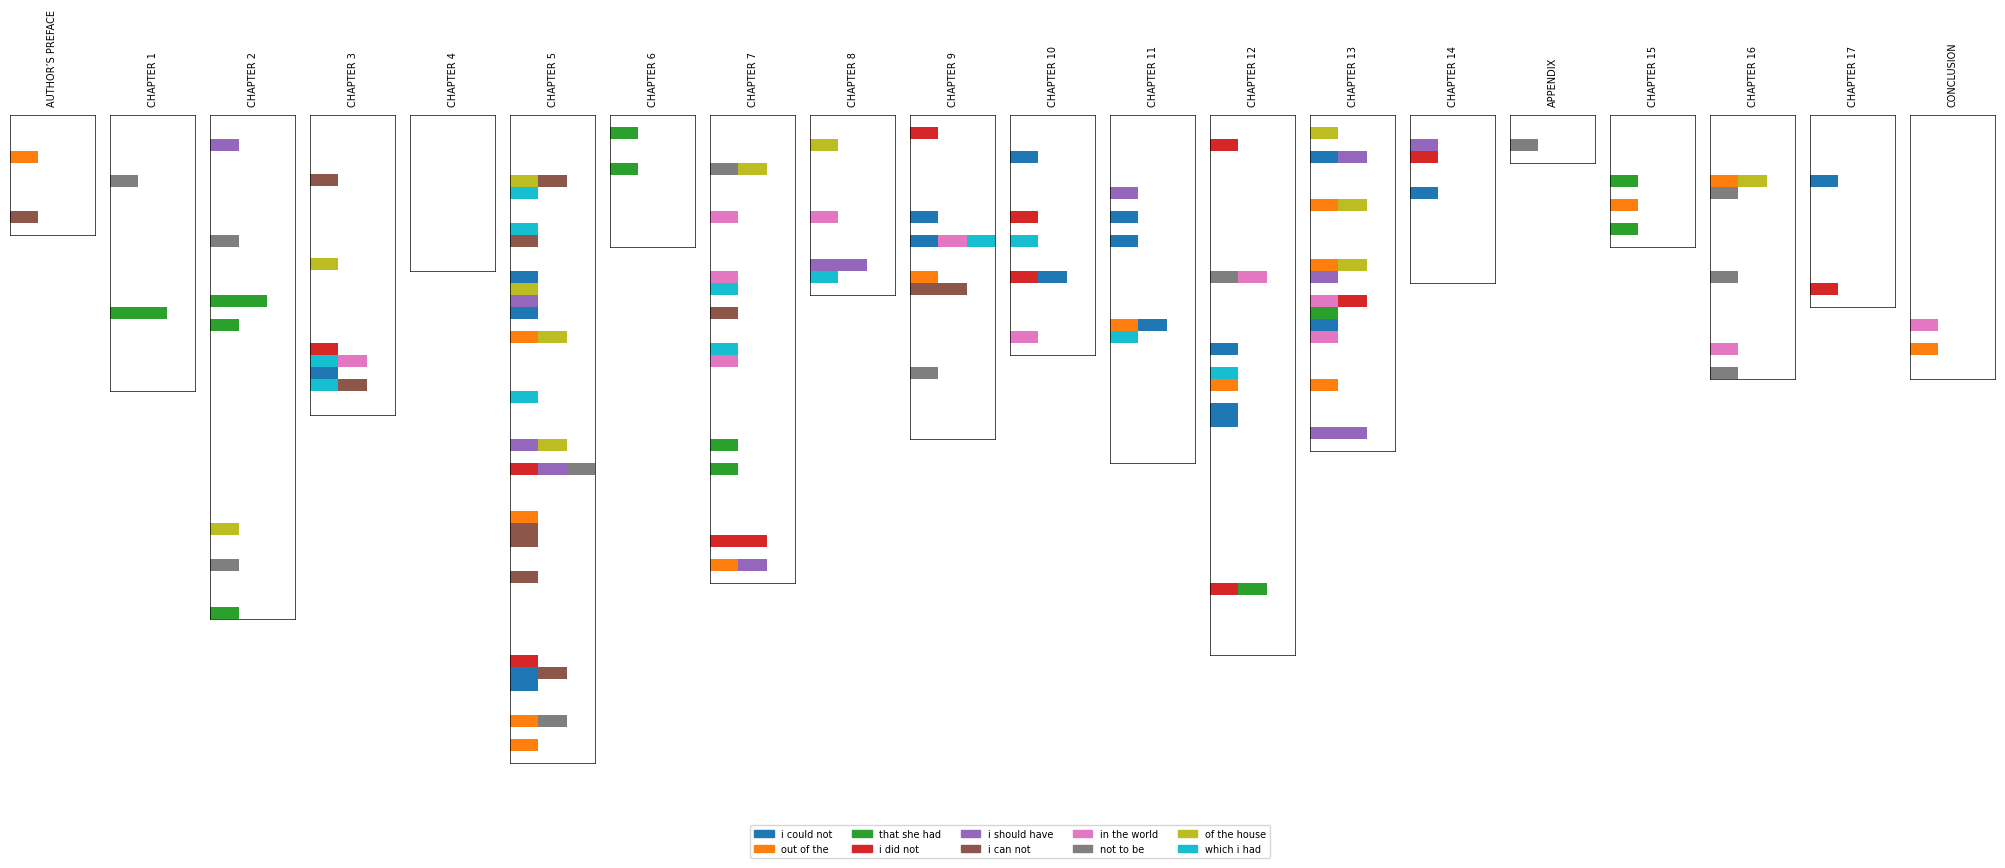

In [22]:
chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)  # uses 'content' column by default
top10 = top_trigrams_across_chapters(chapter_paragraphs, n=10)
fig = plot_trigram_pattern_grid(chapter_paragraphs, top10)
fig.savefig("trigram_grid.png", dpi=200, bbox_inches="tight")

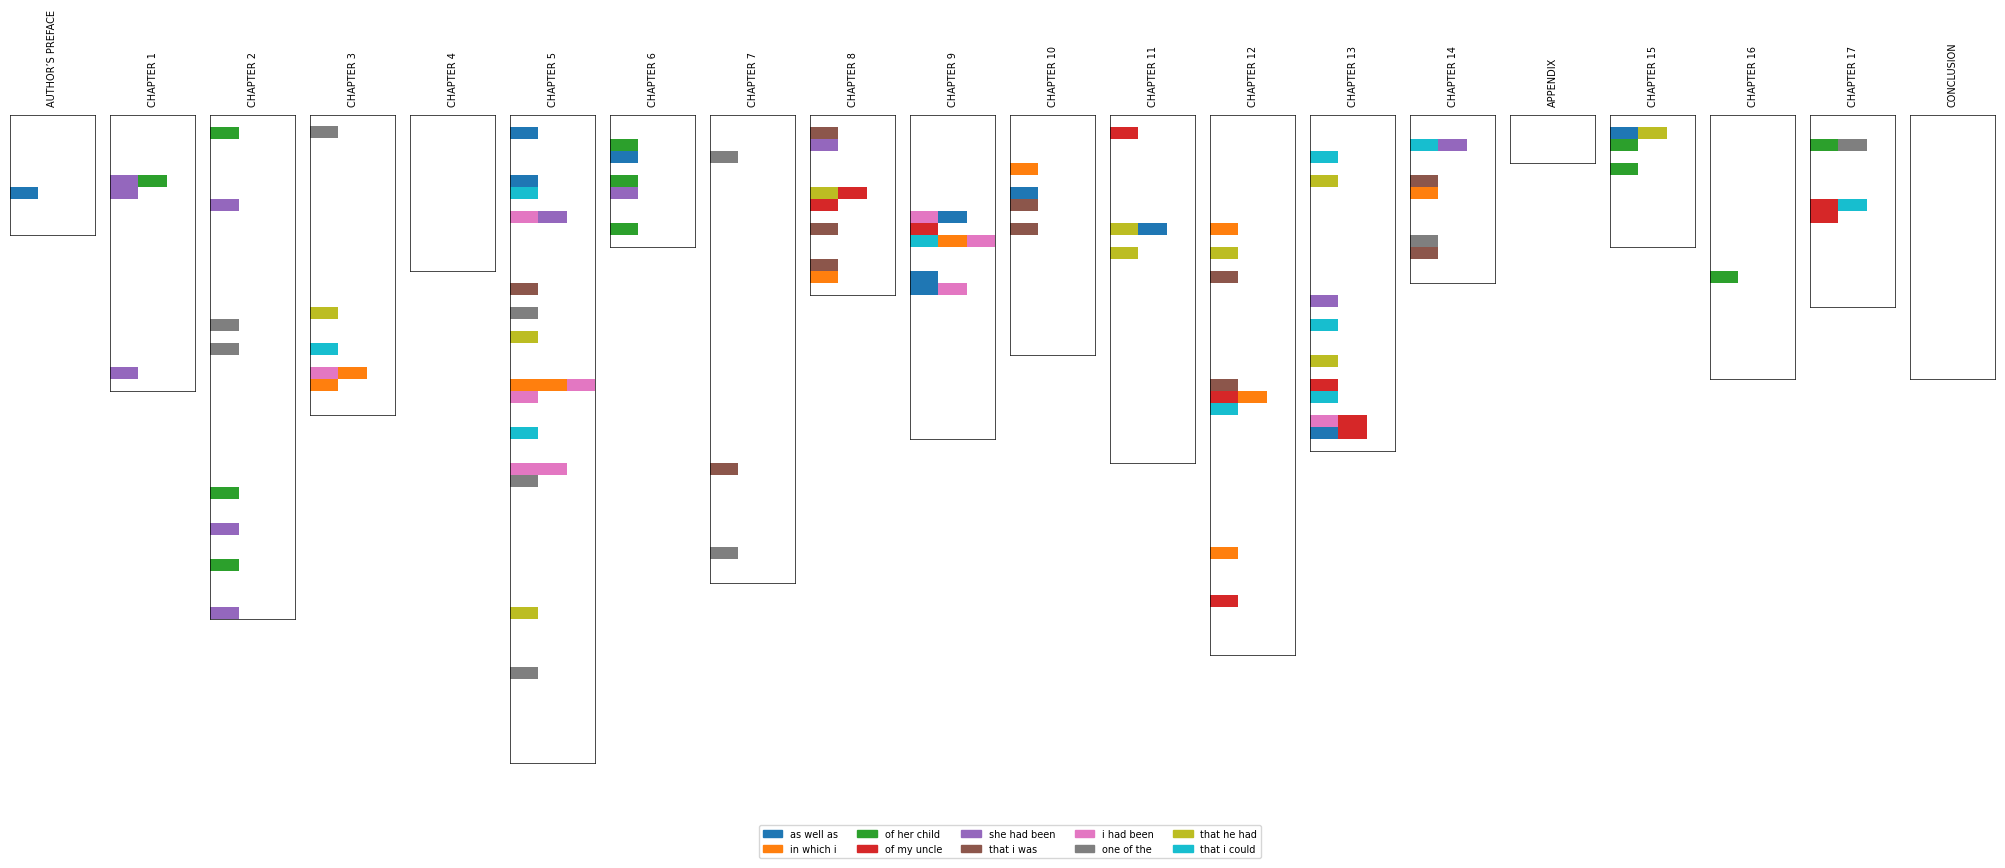

In [23]:
_11_20 = top_trigrams_across_chapters(chapter_paragraphs, offset=10, n=10)
fig = plot_trigram_pattern_grid(chapter_paragraphs, _11_20)
fig.savefig("trigram_grid_11_20.png", dpi=300, bbox_inches="tight")

In [24]:
def ngram_frequency_table(paragraphs: list[str], ns: Iterable[int] = range(3, 30), min_count: int = 2) -> pd.DataFrame:
    """
    Repeated n-grams for every length in `ns`, stacked into one DataFrame:
    columns are n, ngram (tuple), text, total_count, num_paragraphs.
    Only n-grams occurring >= min_count times are kept (min_count=2 means
    "actually repeats at least once"). Sorted by total_count within each n,
    since counts aren't comparable across different n -- filter/sort the
    returned DataFrame however you like, e.g.:

        table[table["n"] == 5].head(10)                    # top 5-grams
        table.sort_values("total_count", ascending=False)   # everything, raw count
        table.assign(score=table.n * table.total_count).sort_values("score", ascending=False)

    n < 3 is rejected: unigrams/bigrams repeat so trivially (function words,
    "of the", etc.) that they just add noise here.
    """
    ns = list(ns)
    if any(n < 3 for n in ns):
        raise ValueError(f"ns must all be >= 3, got {ns}")
    rows = []
    for n in ns:
        corpus = build_trigram_corpus(paragraphs, n=n)
        for gram, count in corpus.trigram_counts.items():
            if count < min_count:
                continue
            rows.append({
                "n": n,
                "ngram": gram,
                "text": " ".join(gram),
                "total_count": count,
                "num_paragraphs": len(corpus.trigram_index[gram]),
            })
    df = pd.DataFrame(rows, columns=["n", "ngram", "text", "total_count", "num_paragraphs"])
    return df.sort_values(["n", "total_count"], ascending=[True, False]).reset_index(drop=True)

In [25]:
all_paragraphs = load_paragraphs(maria)

table = ngram_frequency_table(all_paragraphs)              # n = 3..10, default
table = ngram_frequency_table(all_paragraphs, ns=range(3, 20))  # wider range

table[table["n"] == 5].head(10)                     # top 5-grams by count
table.sort_values("total_count", ascending=False)   

,n,ngram,text,total_count,num_paragraphs
0,3,"(i, could, not)",i could not,19,19
1,3,"(out, of, the)",out of the,15,15
2,3,"(that, she, had)",that she had,14,12
3,3,"(chapter, chapter, chapter)",chapter chapter chapter,13,1
4,3,"(which, i, had)",which i had,13,13
...,...,...,...,...,...
1264,3,"(into, my, hand)",into my hand,2,2
1263,3,"(guinea, into, my)",guinea into my,2,2
1262,3,"(a, guinea, into)",a guinea into,2,2
1261,3,"(in, haste, to)",in haste to,2,2


In [26]:
over_3 = table.loc[table['n'] > 3]

In [27]:
over_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 689 entries, 1984 to 2672
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   n               689 non-null    int64 
 1   ngram           689 non-null    object
 2   text            689 non-null    str   
 3   total_count     689 non-null    int64 
 4   num_paragraphs  689 non-null    int64 
dtypes: int64(3), object(1), str(1)
memory usage: 27.0+ KB


In [28]:
over_3.head(30)

,n,ngram,text,total_count,num_paragraphs
1984,4,"(chapter, chapter, chapter, chapter)",chapter chapter chapter chapter,11,1
1985,4,"(at, the, same, time)",at the same time,9,9
1986,4,"(in, the, midst, of)",in the midst of,6,6
1987,4,"(the, death, of, my)",the death of my,6,6
1988,4,"(was, not, to, be)",was not to be,4,4
1989,4,"(knew, what, it, was)",knew what it was,4,4
1990,4,"(the, greater, part, of)",the greater part of,4,4
1991,4,"(the, present, state, of)",the present state of,4,4
1992,4,"(the, sound, of, a)",the sound of a,4,4
1993,4,"(to, enable, me, to)",to enable me to,4,4


In [29]:
table[table['n']==table['n'].max()]

,n,ngram,text,total_count,num_paragraphs
2672,19,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2


In [30]:
table.sort_values('n', ascending=False).head(60)

,n,ngram,text,total_count,num_paragraphs
2672,19,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2
2671,18,"(exhibiting, the, misery, and, oppression, pec...",exhibiting the misery and oppression peculiar ...,2,2
2670,18,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2
2669,17,"(the, misery, and, oppression, peculiar, to, w...",the misery and oppression peculiar to women th...,2,2
2668,17,"(exhibiting, the, misery, and, oppression, pec...",exhibiting the misery and oppression peculiar ...,2,2
2667,17,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2
2666,16,"(misery, and, oppression, peculiar, to, women,...",misery and oppression peculiar to women that a...,2,2
2665,16,"(the, misery, and, oppression, peculiar, to, w...",the misery and oppression peculiar to women th...,2,2
2664,16,"(exhibiting, the, misery, and, oppression, pec...",exhibiting the misery and oppression peculiar ...,2,2
2663,16,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2


In [31]:
def _find_maximal_repeats(token_lists: list[list[str]], min_n: int, max_n: int, min_count: int) -> list[dict]:
    """
    Core maximal-repeat scan, shared by maximal_repeated_ngrams() and
    maximal_repeated_ngrams_by_chapter(). Operates on a flat list of token
    sequences (one per sentence) and returns a list of dicts: n, gram,
    text, total_count, positions (list of (sequence_idx, start_idx)) --
    sequence_idx indexes back into `token_lists`.

    See maximal_repeated_ngrams()'s docstring for what "maximal" means here.
    """
    rows = []
    for n in range(min_n, max_n + 1):
        gram_positions: dict[tuple[str, ...], list[tuple[int, int]]] = defaultdict(list)
        for seq_idx, tokens in enumerate(token_lists):
            for i in range(len(tokens) - n + 1):
                gram_positions[tuple(tokens[i:i + n])].append((seq_idx, i))

        any_repeats_this_n = False
        for gram, positions in gram_positions.items():
            if len(positions) < min_count:
                continue
            any_repeats_this_n = True

            right_words, left_words = set(), set()
            right_ok, left_ok = True, True
            for seq_idx, i in positions:
                tokens = token_lists[seq_idx]
                if i + n < len(tokens):
                    right_words.add(tokens[i + n])
                else:
                    right_ok = False
                if i - 1 >= 0:
                    left_words.add(tokens[i - 1])
                else:
                    left_ok = False

            right_extendable = right_ok and len(right_words) == 1
            left_extendable = left_ok and len(left_words) == 1
            if right_extendable or left_extendable:
                continue  # redundant -- the longer repeat containing this will surface at n+1

            rows.append({
                "n": n, "gram": gram, "text": " ".join(gram),
                "total_count": len(positions), "positions": positions,
            })

        # No repeats at all at this length -> none possible at any greater
        # length either (a longer repeat implies its sub-windows repeat too).
        if not any_repeats_this_n:
            break

    return rows

In [32]:
def maximal_repeated_ngrams(
    paragraphs: list[str], min_n: int = 3, max_n: int = 40, min_count: int = 2
) -> pd.DataFrame:
    """
    Repeated n-grams, but only the MAXIMAL ones: a repeat is dropped if it
    can be extended -- left or right -- while every one of its occurrences
    shares the same extending word. That's the direct fix for nesting: an
    18-gram that's always immediately followed by the same word at both its
    occurrences isn't an independent repeat, it's a truncated view of the
    19-gram repeat, so it's redundant and gets dropped; only the 19-gram
    (or whatever the true maximal length turns out to be) survives.

    This checks actual token adjacency at each occurrence, not just whether
    counts happen to match between separately-built n and n+1 tables --
    the latter can be fooled by coincidental equal counts from unrelated
    patterns; this can't.
    """
    # Tokenize once; positions (sentence index into this list, start offset)
    # stay comparable across every n we check.
    seq_paragraph: list[int] = []
    token_lists: list[list[str]] = []
    for pid, para in enumerate(paragraphs):
        for sent in paragraph_to_sentences(para):
            seq_paragraph.append(pid)
            token_lists.append(sent)

    repeats = _find_maximal_repeats(token_lists, min_n, max_n, min_count)

    rows = []
    for r in repeats:
        pids = {seq_paragraph[seq_idx] for seq_idx, _i in r["positions"]}
        rows.append({
            "n": r["n"], "ngram": r["gram"], "text": r["text"],
            "total_count": r["total_count"], "num_paragraphs": len(pids),
        })

    df = pd.DataFrame(rows, columns=["n", "ngram", "text", "total_count", "num_paragraphs"])
    return df.sort_values(["n", "total_count"], ascending=[True, False]).reset_index(drop=True)


def maximal_repeated_ngrams_by_chapter(
    chapter_paragraphs: dict[str, list[str]], min_n: int = 3, max_n: int = 40, min_count: int = 2
) -> pd.DataFrame:
    """
    Long-format version of maximal_repeated_ngrams(): one row per
    OCCURRENCE rather than one row per pattern, with its chapter and a
    global paragraph location -- the shape plot_ngram_3d_scatter() needs
    for a location/length/frequency plot colored by chapter.

    chapter_paragraphs: {chapter_name: [paragraph, ...]}, e.g. from
        build_chapter_paragraphs(maria_chapters_df)

    Columns: n, ngram, text, total_count (repeat frequency of the pattern
    -- the same value repeated across all its occurrence rows), chapter,
    location (paragraph index counted across all chapters combined, in
    the order chapter_paragraphs was given -- i.e. book reading order).
    """
    seq_meta: list[tuple[str, int]] = []  # (chapter, global_paragraph_id) per sentence
    token_lists: list[list[str]] = []
    global_pid = 0
    for chapter, paras in chapter_paragraphs.items():
        for para in paras:
            for sent in paragraph_to_sentences(para):
                seq_meta.append((chapter, global_pid))
                token_lists.append(sent)
            global_pid += 1

    repeats = _find_maximal_repeats(token_lists, min_n, max_n, min_count)

    rows = []
    for r in repeats:
        for seq_idx, _i in r["positions"]:
            chapter, location = seq_meta[seq_idx]
            rows.append({
                "n": r["n"], "ngram": r["gram"], "text": r["text"],
                "total_count": r["total_count"], "chapter": chapter, "location": location,
            })

    df = pd.DataFrame(rows, columns=["n", "ngram", "text", "total_count", "chapter", "location"])
    return df.sort_values(["total_count", "n"], ascending=[False, False]).reset_index(drop=True)

In [33]:
table = maximal_repeated_ngrams(all_paragraphs, min_n=3, max_n=40, min_count=2)
table.sort_values("total_count", ascending=False)

,n,ngram,text,total_count,num_paragraphs
0,3,"(i, could, not)",i could not,19,19
1,3,"(out, of, the)",out of the,15,15
2,3,"(that, she, had)",that she had,14,12
3,3,"(chapter, chapter, chapter)",chapter chapter chapter,13,1
4,3,"(which, i, had)",which i had,13,13
...,...,...,...,...,...
977,3,"(a, tithe, of)",a tithe of,2,2
976,3,"(scarcely, conceive, the)",scarcely conceive the,2,2
975,3,"(place, in, a)",place in a,2,2
974,3,"(to, accept, of)",to accept of,2,2


In [34]:
table.sort_values("n", ascending=False).head(30)

,n,ngram,text,total_count,num_paragraphs
1875,19,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2
1874,13,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,2,1
1873,12,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,3,1
1872,11,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,4,1
1871,10,"(the, introduction, of, darnford, as, the, del...",the introduction of darnford as the deliverer ...,2,2
1870,10,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,5,1
1869,9,"(to, have, been, an, after, thought, of, the, ...",to have been an after thought of the author,2,2
1868,9,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,6,1
1865,8,"(chapter, chapter, chapter, chapter, chapter, ...",chapter chapter chapter chapter chapter chapte...,7,1
1866,8,"(he, knew, not, what, it, was, to, feel)",he knew not what it was to feel,2,2


In [35]:
table.iloc[1863]

n                                                                 7
ngram             (chapter, chapter, chapter, chapter, chapter, ...
text              chapter chapter chapter chapter chapter chapte...
total_count                                                       8
num_paragraphs                                                    1
Name: 1863, dtype: object

In [36]:
def drop_degenerate_ngrams(df: pd.DataFrame, min_unique_tokens: int = 2) -> pd.DataFrame:
    """
    Filter out rows whose ngram is (near-)degenerate repetition of a single
    word -- e.g. ('chapter', 'chapter', ..., 'chapter') from a Gutenberg
    table of contents or running page header. Works on the output of either
    ngram_frequency_table() or maximal_repeated_ngrams(), since both share
    the same 'ngram' column.

    min_unique_tokens=2 (the default) drops only pure single-word repeats.
    Raise it to also drop low-diversity ngrams like ('chapter', 'one',
    'chapter', 'two', 'chapter', 'three') if those show up as artifacts too.
    """
    keep = df["ngram"].apply(lambda g: len(set(g)) >= min_unique_tokens)
    return df[keep].reset_index(drop=True)

In [37]:
table = drop_degenerate_ngrams(table)

In [38]:
table.sort_values('n', ascending=False).head(30)

,n,ngram,text,total_count,num_paragraphs
1864,19,"(of, exhibiting, the, misery, and, oppression,...",of exhibiting the misery and oppression peculi...,2,2
1863,10,"(the, introduction, of, darnford, as, the, del...",the introduction of darnford as the deliverer ...,2,2
1862,9,"(to, have, been, an, after, thought, of, the, ...",to have been an after thought of the author,2,2
1861,8,"(scattered, heads, for, the, continuation, of,...",scattered heads for the continuation of the story,2,2
1860,8,"(he, knew, not, what, it, was, to, feel)",he knew not what it was to feel,2,2
1859,7,"(seemed, to, open, a, new, world, to)",seemed to open a new world to,2,2
1852,6,"(i, prevailed, on, my, uncle, to)",i prevailed on my uncle to,2,2
1846,6,"(the, events, of, her, past, life)",the events of her past life,2,2
1847,6,"(on, the, present, state, of, society)",on the present state of society,2,2
1848,6,"(it, was, a, part, of, my)",it was a part of my,2,1


In [39]:
table.sort_values('total_count', ascending=False).head(30)

,n,ngram,text,total_count,num_paragraphs
0,3,"(i, could, not)",i could not,19,19
1,3,"(out, of, the)",out of the,15,15
2,3,"(that, she, had)",that she had,14,12
3,3,"(which, i, had)",which i had,13,13
4,3,"(i, should, have)",i should have,13,11
5,3,"(i, did, not)",i did not,13,12
8,3,"(not, to, be)",not to be,12,12
10,3,"(in, the, world)",in the world,12,12
9,3,"(of, the, house)",of the house,12,12
7,3,"(i, can, not)",i can not,12,11


In [40]:
table.sort_values('total_count', ascending=False).iloc[30:60]

,n,ngram,text,total_count,num_paragraphs
28,3,"(i, had, no)",i had no,8,8
27,3,"(i, was, not)",i was not,8,8
26,3,"(it, was, to)",it was to,8,8
43,3,"(it, was, a)",it was a,7,6
53,3,"(of, my, husband)",of my husband,7,6
52,3,"(when, i, was)",when i was,7,7
51,3,"(i, determined, to)",i determined to,7,6
50,3,"(he, had, been)",he had been,7,6
48,3,"(a, part, of)",a part of,7,6
47,3,"(two, or, three)",two or three,7,7


In [41]:
def repetition_id_table(
    chapter_paragraphs: dict[str, list[str]], min_n: int = 3, max_n: int = 40, min_count: int = 2
) -> pd.DataFrame:
    """
    One row per unique repeated pattern (a "repetition ID" in the
    article's terms), not one row per occurrence -- this is what Figs
    9-11 actually plot. Each repeated sequence becomes a single
    combinatory object carrying: its length, its total frequency, where
    it FIRST occurs, and where it LAST occurs (location + chapter for
    each). Plotting one object per pattern instead of one per occurrence
    is exactly what keeps the graph from being noisy with repeated points
    for the same pattern.

    chapter_paragraphs: {chapter_name: [paragraph, ...]}, e.g. from
        build_chapter_paragraphs(maria_chapters_df)

    Columns: n, ngram, text, total_count, first_location, first_chapter,
    last_location, last_chapter. Locations are paragraph indices counted
    across all chapters combined, in the order chapter_paragraphs was
    given (i.e. book reading order) -- same convention as
    maximal_repeated_ngrams_by_chapter().
    """
    seq_meta: list[tuple[str, int]] = []  # (chapter, global_paragraph_id) per sentence
    token_lists: list[list[str]] = []
    global_pid = 0
    for chapter, paras in chapter_paragraphs.items():
        for para in paras:
            for sent in paragraph_to_sentences(para):
                seq_meta.append((chapter, global_pid))
                token_lists.append(sent)
            global_pid += 1

    repeats = _find_maximal_repeats(token_lists, min_n, max_n, min_count)

    rows = []
    for r in repeats:
        occurrence_locs = sorted(
            (seq_meta[seq_idx] for seq_idx, _i in r["positions"]),
            key=lambda chapter_and_pid: chapter_and_pid[1],  # book order
        )
        first_chapter, first_location = occurrence_locs[0]
        last_chapter, last_location = occurrence_locs[-1]
        rows.append({
            "n": r["n"], "ngram": r["gram"], "text": r["text"],
            "total_count": r["total_count"],
            "first_location": first_location, "first_chapter": first_chapter,
            "last_location": last_location, "last_chapter": last_chapter,
        })

    df = pd.DataFrame(rows, columns=[
        "n", "ngram", "text", "total_count",
        "first_location", "first_chapter", "last_location", "last_chapter",
    ])
    return df.sort_values("first_location").reset_index(drop=True)

In [69]:
# def plot_ngram_3d_scatter(
#     repetition_df: pd.DataFrame,
#     chapter_order: list[str],
#     block_size: tuple[float, float, float] | None = None,
#     figsize: tuple[float, float] = (14, 8),
#     cmap_name: str | None = None,
#     elev: float = 18,
#     azim: float = -80,
#     box_aspect: tuple[float, float, float] = (2.5, 2.2, 1.4),
#     invert_length_axis: bool = True,
# ):
#     """
#     3D scatter of EVERY OCCURRENCE of every repeated maximal n-gram.

#     This function expects the output of
#     maximal_repeated_ngrams_by_chapter(), merged with first_chapter
#     information from repetition_id_table().

#     Coordinates:
#         x = location in the novel (global paragraph index)
#         y = n-gram length
#         z = total_count (number of times this n-gram occurs in the novel)

#     Color:
#         chapter of the FIRST occurrence of the repeated n-gram.

#     Thus, if a 10-gram first appears in Chapter 1 and occurs again
#     in Chapters 3 and 5, all three blocks receive the Chapter 1 color.

#     repetition_df:
#         Output of maximal_repeated_ngrams_by_chapter(), merged with
#         first_chapter from repetition_id_table().

#         Required columns:
#             n
#             total_count
#             location
#             first_chapter

#     block_size:
#         (dx, dy, dz) in data units.

#         If None, dx is scaled to the range of paragraph locations, while
#         dy and dz remain small fixed sizes appropriate for the n-gram
#         length and frequency axes.

#     elev, azim:
#         Camera angle.

#     box_aspect:
#         Relative proportions of the x, y, and z dimensions.

#     invert_length_axis:
#         If True, shorter n-grams appear toward the back and longer
#         n-grams toward the front.
#     """

#     chapters = chapter_order
#     n_colors = len(chapters)

#     cmap_name = cmap_name or ("tab10" if n_colors <= 10 else "tab20")
#     palette = list(plt.get_cmap(cmap_name).colors)

#     chapter_color = {
#         chapter: palette[i % len(palette)]
#         for i, chapter in enumerate(chapters)
#     }

#     # ---------------------------------------------------------------
#     # Size of each block
#     # ---------------------------------------------------------------

#     if block_size is None:
#         loc_range = (
#             repetition_df["location"].max()
#             - repetition_df["location"].min()
#         )

#         dx = max(loc_range * 0.01, 1.0)

#         block_size = (dx, 0.6, 0.6)

#     dx, dy, dz = block_size

#     # ---------------------------------------------------------------
#     # Create figure
#     # ---------------------------------------------------------------

#     fig = plt.figure(figsize=figsize)

#     ax = fig.add_subplot(111, projection="3d")

#     ax.set_box_aspect(box_aspect)

#     ax.view_init(
#         elev=elev,
#         azim=azim,
#     )

#     if invert_length_axis:
#         ax.invert_yaxis()

#     # ---------------------------------------------------------------
#     # Plot EVERY occurrence
#     # ---------------------------------------------------------------

#     for chapter in chapters:

#         sub = repetition_df[
#             repetition_df["first_chapter"] == chapter
#         ]

#         if sub.empty:
#             continue

#         xs = (
#             sub["location"].to_numpy(dtype=float)
#             - dx / 2
#         )

#         ys = (
#             sub["n"].to_numpy(dtype=float)
#             - dy / 2
#         )

#         zs = (
#             sub["total_count"].to_numpy(dtype=float)
#             - dz / 2
#         )

#         ax.bar3d(
#             xs,
#             ys,
#             zs,
#             dx,
#             dy,
#             dz,
#             color=chapter_color[chapter],
#             shade=False,
#         )

#     # ---------------------------------------------------------------
#     # Axes
#     # ---------------------------------------------------------------

#     ax.set_xlabel(
#         "Location in novel (paragraph index, book order)"
#     )

#     ax.set_ylabel(
#         "N-gram length"
#     )

#     ax.set_zlabel(
#         "Frequency (occurrence count)"
#     )

#     ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#     # ---------------------------------------------------------------
#     # Legend
#     # ---------------------------------------------------------------

#     legend_patches = [
#         mpatches.Patch(
#             color=chapter_color[chapter],
#             label=chapter
#         )
#         for chapter in chapters
#     ]

#     ax.legend(
#         handles=legend_patches,
#         loc="upper left",
#         bbox_to_anchor=(1.02, 1.0),
#         fontsize=7,
#         title="First-occurrence chapter",
#     )

#     return fig

In [55]:
# chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)
# rep_table = repetition_id_table(chapter_paragraphs, min_n=3, max_n=40)
# rep_table = drop_degenerate_ngrams(rep_table)

# fig = plot_ngram_3d_scatter(rep_table, chapter_order=list(maria_chapters_df.index))
# fig.savefig("repetition_ids_3d.png", dpi=200, bbox_inches="tight")

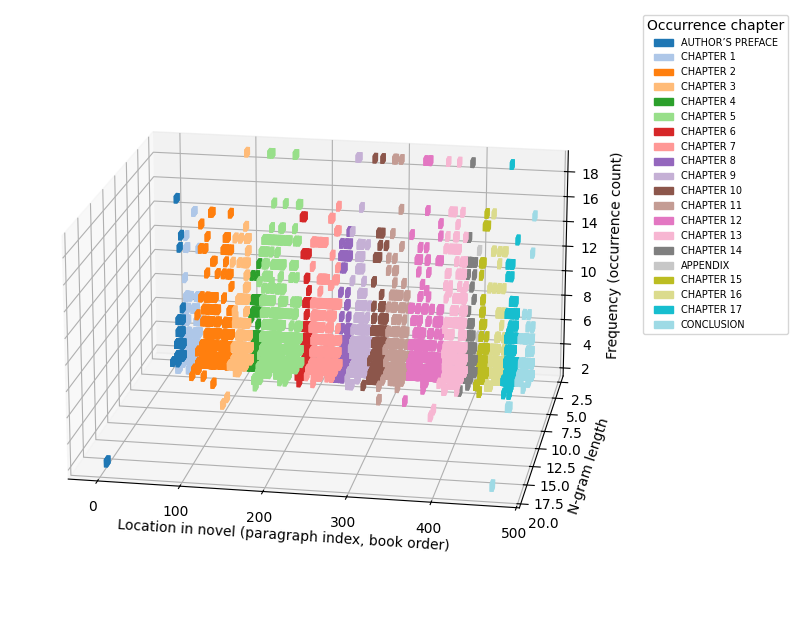

In [44]:
chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)
rep_table = maximal_repeated_ngrams_by_chapter(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

rep_table = drop_degenerate_ngrams(rep_table)

fig = plot_ngram_3d_scatter(rep_table, chapter_order=list(maria_chapters_df.index))
fig.savefig("repetition_ids_3d.png", dpi=200, bbox_inches="tight")

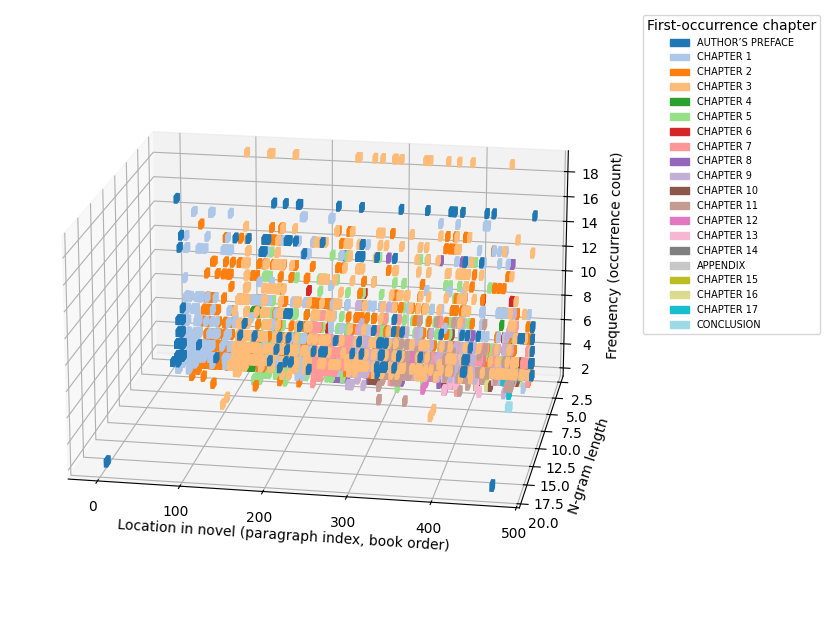

In [48]:
chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)

repetition_ids = repetition_id_table(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = maximal_repeated_ngrams_by_chapter(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = drop_degenerate_ngrams(
    repetition_occurrences
)

repetition_occurrences = repetition_occurrences.merge(
    repetition_ids[["n", "ngram", "first_chapter"]],
    on=["n", "ngram"],
    how="left"
)

fig = plot_ngram_3d_scatter(
    repetition_occurrences,
    chapter_order=list(maria_chapters_df.index)
)

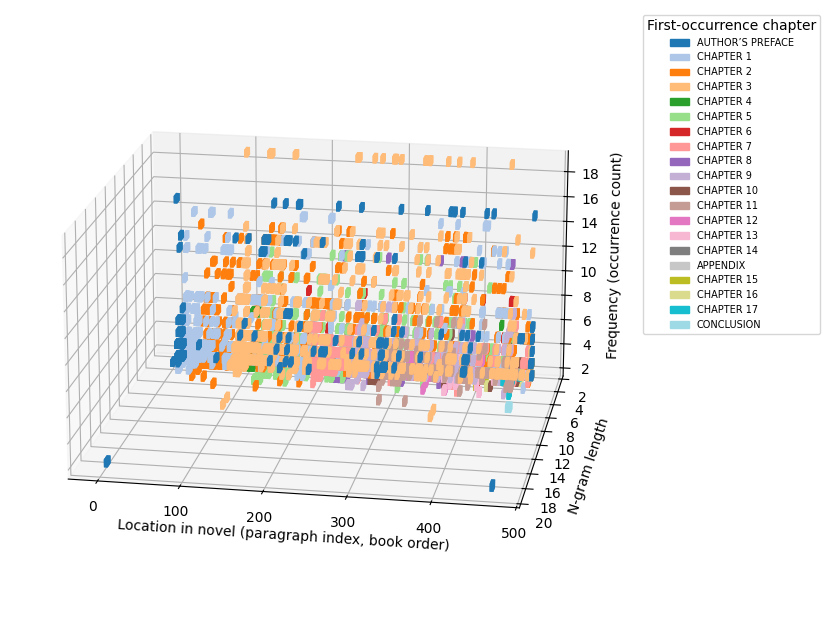

In [70]:
chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)

repetition_ids = repetition_id_table(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = maximal_repeated_ngrams_by_chapter(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = drop_degenerate_ngrams(
    repetition_occurrences
)

repetition_occurrences = repetition_occurrences.merge(
    repetition_ids[["n", "ngram", "first_chapter"]],
    on=["n", "ngram"],
    how="left"
)

fig = plot_ngram_3d_scatter(
    repetition_occurrences,
    chapter_order=list(maria_chapters_df.index)
)

In [68]:
print(repetition_occurrences[["n", "total_count"]].describe())
print()
print("Max n:", repetition_occurrences["n"].max())
print("Max frequency:", repetition_occurrences["total_count"].max())
print()
print(
    repetition_occurrences
    .sort_values("total_count", ascending=False)
    [["n", "text", "total_count", "location", "first_chapter"]]
    .head(10)
)

                 n  total_count
count  4853.000000  4853.000000
mean      3.190604     3.466516
std       0.612573     2.591357
min       3.000000     2.000000
25%       3.000000     2.000000
50%       3.000000     2.000000
75%       3.000000     4.000000
max      19.000000    19.000000

Max n: 19
Max frequency: 19

    n         text  total_count  location first_chapter
0   3  i could not           19        96     CHAPTER 3
10  3  i could not           19       289     CHAPTER 3
1   3  i could not           19       126     CHAPTER 3
18  3  i could not           19       437     CHAPTER 3
17  3  i could not           19       387     CHAPTER 3
16  3  i could not           19       370     CHAPTER 3
15  3  i could not           19       356     CHAPTER 3
14  3  i could not           19       333     CHAPTER 3
12  3  i could not           19       327     CHAPTER 3
11  3  i could not           19       296     CHAPTER 3


In [140]:
def plot_ngram_3d_scatter(
    repetition_df: pd.DataFrame,
    chapter_order: list[str],
    block_size: tuple[float, float, float] | None = None,
    figsize: tuple[float, float] = (14, 8),
    cmap_name: str | None = None,
    elev: float = 30,
    azim: float = -110,
    box_aspect: tuple[float, float, float] = (2.5, 2.2, 1.4),
    invert_length_axis: bool = True
):
    """
    3D scatter of EVERY OCCURRENCE of every repeated maximal n-gram.

    This function expects the output of
    maximal_repeated_ngrams_by_chapter(), merged with first_chapter
    information from repetition_id_table().

    Coordinates:
        x = location in the novel (global paragraph index)
        y = n-gram length
        z = total_count (number of times this n-gram occurs in the novel)

    Color:
        chapter of the FIRST occurrence of the repeated n-gram.

    Thus, if a 10-gram first appears in Chapter 1 and occurs again
    in Chapters 3 and 5, all three blocks receive the Chapter 1 color.

    repetition_df:
        Output of maximal_repeated_ngrams_by_chapter(), merged with
        first_chapter from repetition_id_table().

        Required columns:
            n
            total_count
            location
            first_chapter

    block_size:
        (dx, dy, dz) in data units.

        If None, dx is scaled to the range of paragraph locations, while
        dy and dz remain small fixed sizes appropriate for the n-gram
        length and frequency axes.

    elev, azim:
        Camera angle.

    box_aspect:
        Relative proportions of the x, y, and z dimensions.

    invert_length_axis:
        If True, shorter n-grams appear toward the back and longer
        n-grams toward the front.
    """

    chapters = chapter_order
    n_colors = len(chapters)

    cmap_name = cmap_name or ("tab10" if n_colors <= 10 else "tab20")
    palette = list(plt.get_cmap(cmap_name).colors)

    chapter_color = {
        chapter: palette[i % len(palette)]
        for i, chapter in enumerate(chapters)
    }

    # ---------------------------------------------------------------
    # Size of each block
    # ---------------------------------------------------------------

    if block_size is None:
        loc_range = (
            repetition_df["location"].max()
            - repetition_df["location"].min()
        )

        dx = max(loc_range * 0.01, 1.0)

        block_size = (dx, 0.6, 0.6)

    dx, dy, dz = block_size

    # ---------------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------------

    fig = plt.figure(figsize=figsize)

    ax = fig.add_subplot(111, projection="3d")

    ax.set_box_aspect(box_aspect)

    ax.view_init(
        elev=elev,
        azim=azim,
    )

    # ---------------------------------------------------------------
    # Plot EVERY occurrence
    # ---------------------------------------------------------------

    for chapter in chapters:

        sub = repetition_df[
            repetition_df["first_chapter"] == chapter
        ]

        if sub.empty:
            continue

        xs = (
            sub["location"].to_numpy(dtype=float)
            - dx / 2
        )

        ys = (
            sub["n"].to_numpy(dtype=float)
            - dy / 2
        )

        zs = (
            sub["total_count"].to_numpy(dtype=float)
            - dz / 2
        )

        ax.bar3d(
            xs,
            ys,
            zs,
            dx,
            dy,
            dz,
            color=chapter_color[chapter],
            shade=False,
        )

    # ---------------------------------------------------------------
    # Axes
    # ---------------------------------------------------------------

    
    n_min = repetition_df["n"].min()
    n_max = repetition_df["n"].max()
    freq_min = repetition_df["total_count"].min()
    freq_max = repetition_df["total_count"].max()
    loc_min = repetition_df["location"].min()
    loc_max = repetition_df["location"].max()

    ax.set_xlabel(
        "Location in novel (paragraph index, book order)"
    )
    ax.set_ylabel(
        "N-gram length"
    )
    ax.set_zlabel(
        "Frequency (occurrence count)"
    )

    pad_frac = 0.05  # 5% of each axis's range, added as breathing room

    n_pad = max((n_max - n_min) * pad_frac, 1)
    freq_pad = max((freq_max - freq_min) * pad_frac, 1)
    loc_pad = max((loc_max - loc_min) * pad_frac, dx)

    ax.set_xlim3d(loc_min - dx / 2 - loc_pad, loc_max + dx / 2 + loc_pad)
    ax.set_ylim3d(n_min - dy / 2 - n_pad, n_max + dy / 2 + n_pad)
    if invert_length_axis:
        ax.invert_yaxis()
    ax.set_zlim3d(freq_min - dz / 2, freq_max + dz / 2 + freq_pad)

    n_tick_step = max(1, math.ceil((n_max - n_min) / 8))
    ax.set_yticks(np.arange(n_min, n_max + 1, n_tick_step))
    ax.zaxis.set_major_locator(MaxNLocator(integer=True))

    ax.tick_params(axis="y", pad=4)

    for label in ax.yaxis.get_ticklabels():
        label.set_verticalalignment("bottom")

    # ---------------------------------------------------------------
    # Legend
    # ---------------------------------------------------------------

    legend_patches = [
        mpatches.Patch(
            color=chapter_color[chapter],
            label=chapter
        )
        for chapter in chapters
    ]

    ax.legend(
        handles=legend_patches,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=7,
        title="First-occurrence chapter",
    )

    return fig

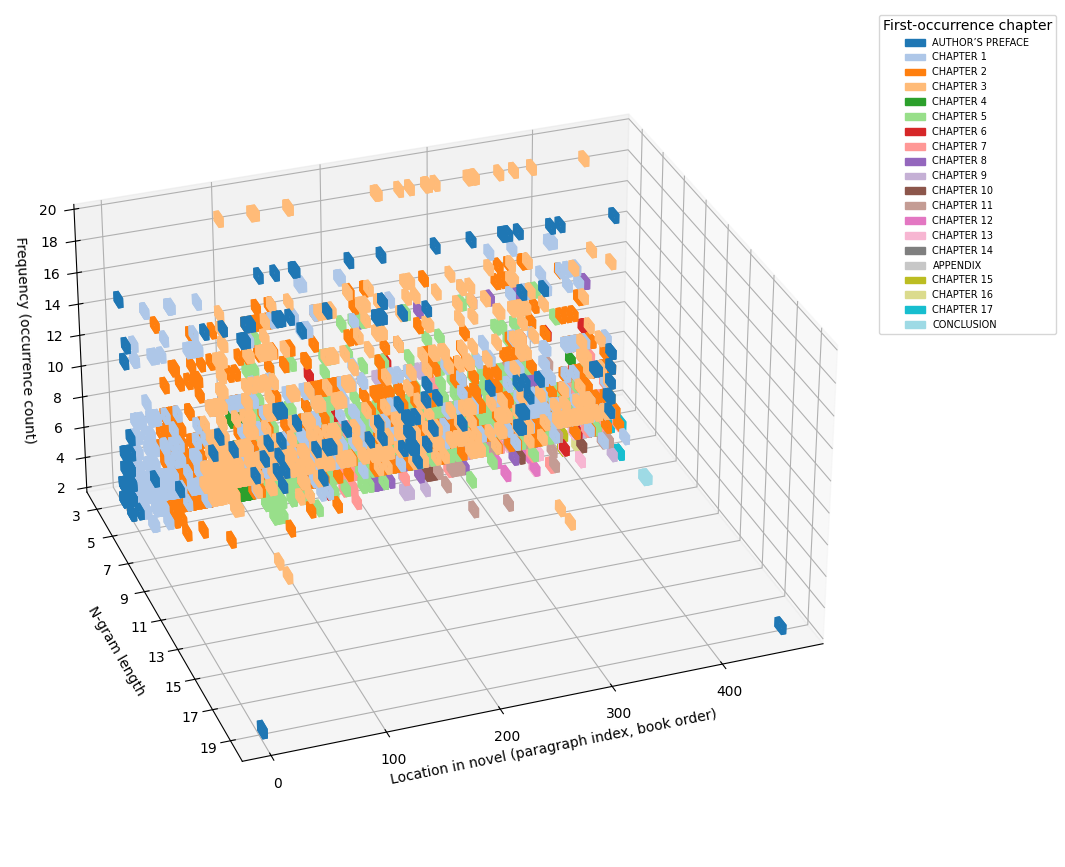

In [141]:
chapter_paragraphs = build_chapter_paragraphs(maria_chapters_df)

repetition_ids = repetition_id_table(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = maximal_repeated_ngrams_by_chapter(
    chapter_paragraphs,
    min_n=3,
    max_n=40
)

repetition_occurrences = drop_degenerate_ngrams(
    repetition_occurrences
)

repetition_occurrences = repetition_occurrences.merge(
    repetition_ids[["n", "ngram", "first_chapter"]],
    on=["n", "ngram"],
    how="left"
)

fig = plot_ngram_3d_scatter(
    repetition_occurrences,
    chapter_order=list(maria_chapters_df.index),
    figsize=(18, 11)
)

In [142]:
fig.savefig("repetition_ids_3d.png", dpi=300, bbox_inches="tight")